### Import Necessary Libraries

In [223]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize

### Load Dataset

In [224]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')

### Exploratory Data Analysis

In [225]:
# Data Shape and Information
print ("Shape of data: {}" . format (df.shape))
print ("Number of rows: {}" . format (df.shape [0]))
print ("Number of columns: {}" . format (df.shape [1]))

Shape of data: (2240, 29)
Number of rows: 2240
Number of columns: 29


In [226]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [227]:
df.columns.size

29

In [233]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

Text(0.5, 1.0, 'Visualization of raw customer purchase data')

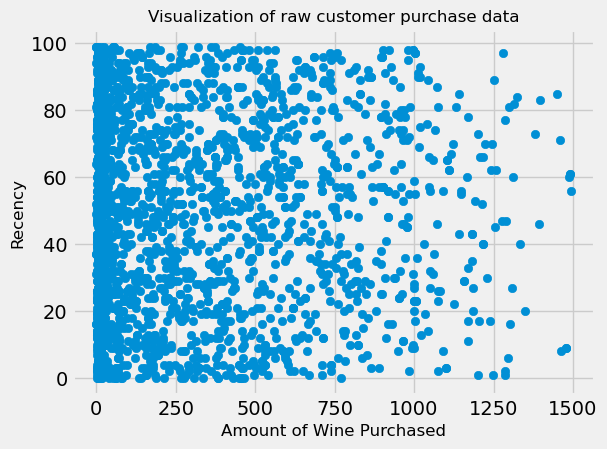

In [237]:
# Visualize Raw Data
plt.figure(figsize = (6,4.5))
plt.scatter (df.iloc[:, 9], df.iloc[:, 8])
plt.xlabel('Amount of Wine Purchased', fontsize = 12)
plt.ylabel('Recency', fontsize = 12)
plt.title('Visualization of raw customer purchase data', fontsize = 12)

This plot helps us to identify customers who are at risk of churning (by how recently a customer has made a purchase) and who are also high-value customers (by the amount of money that a customer has spent on wine in the past year. However, this is a very vague conclusion so we need to apply PCA and clustering algorithm to better understand our data.

In [238]:
# Dataset Summary
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [240]:
# Check for Missing Values
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [241]:
df.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [242]:
# Check for Duplicates
print ("Duplicate values in df are:" , df.duplicated ().sum ())

Duplicate values in df are: 0


<Axes: xlabel='MntMeatProducts'>

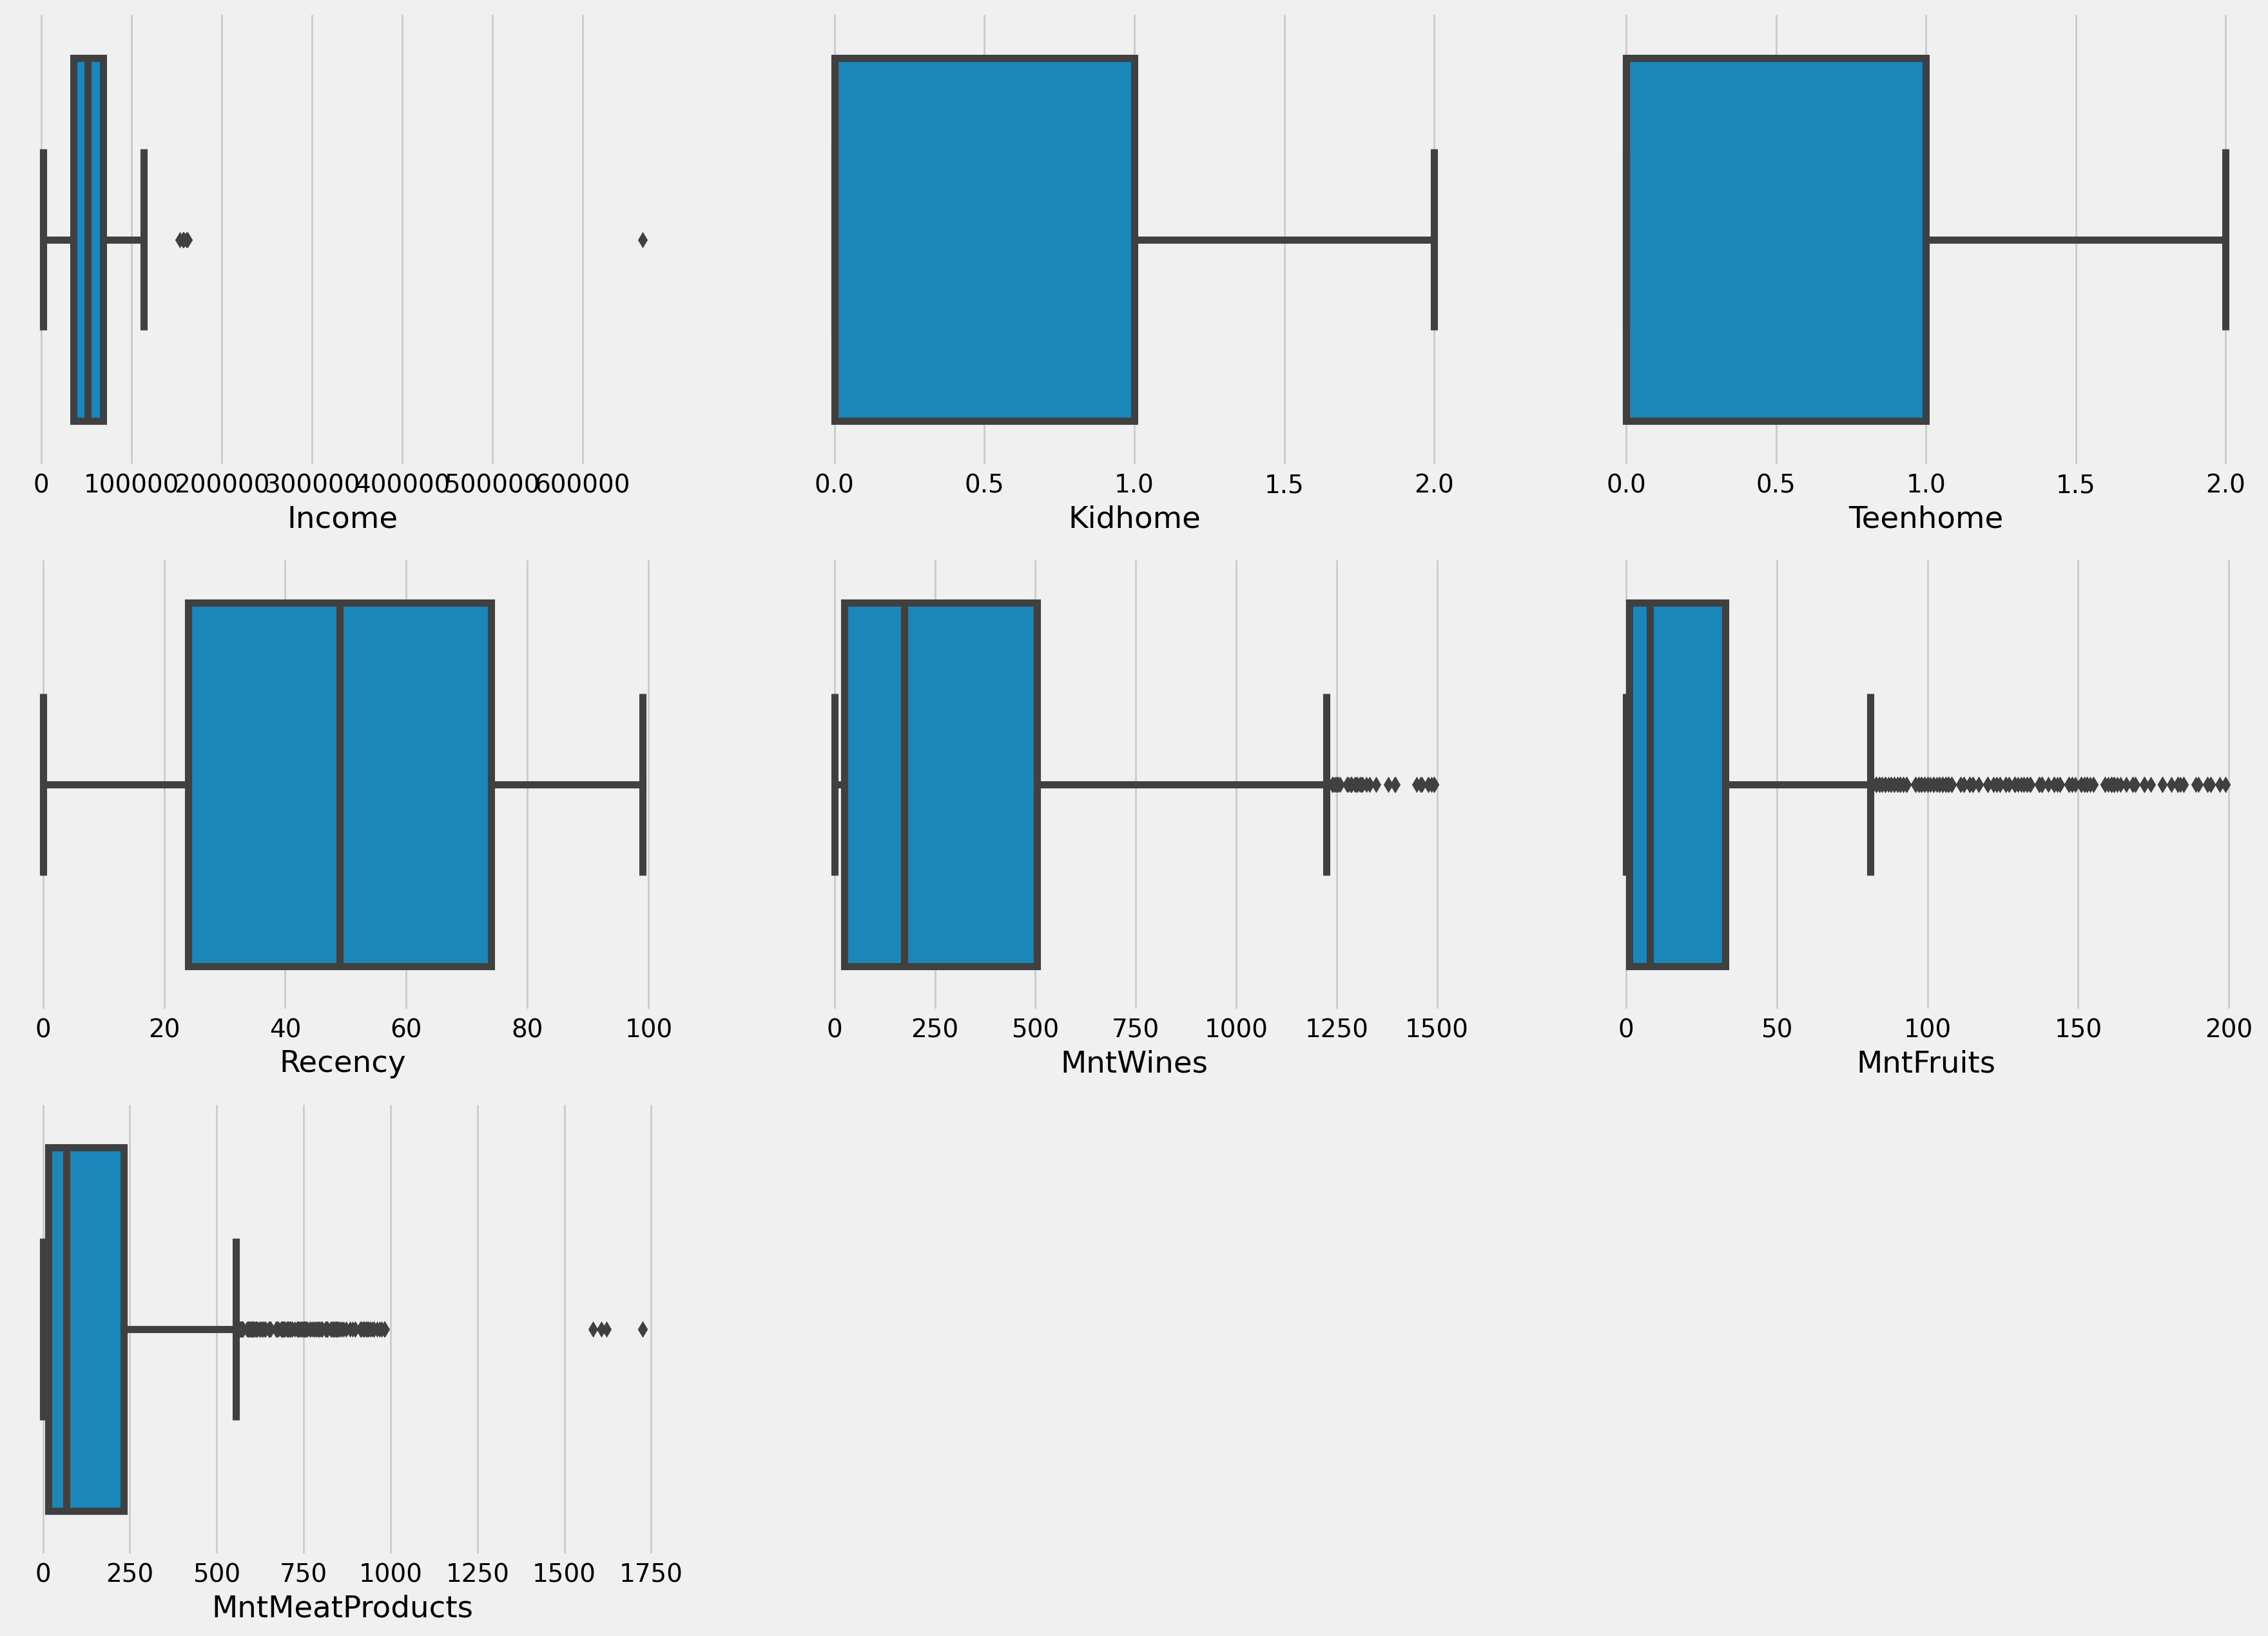

In [243]:
# Check for Outliers
plt.figure(figsize=(20,20), dpi=200)

plt.subplot(4,3,1)
sns.boxplot(x = 'Income', data = df)

plt.subplot(4,3,2)
sns.boxplot(x = 'Kidhome', data = df)

plt.subplot(4,3,3)
sns.boxplot(x = 'Teenhome', data = df)

plt.subplot(4,3,4)
sns.boxplot(x = 'Recency', data = df)

plt.subplot(4,3,5)
sns.boxplot(x = 'MntWines', data = df)

plt.subplot(4,3,6)
sns.boxplot(x = 'MntFruits', data = df)

plt.subplot(4,3,7)
sns.boxplot(x = 'MntMeatProducts', data = df)


### Data Preprocessing

#### Feature Engineering

In [245]:
df ['Age'] = 2024 - df['Year_Birth']

In [244]:
df.Marital_Status.unique() 

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [248]:
# now let us reduce this categories into 2 i.e. in_relationship (2) and not_in_relationship (1)
cust_rnship = {
    'Single' : 1,
    'Together' : 2,
    'Married' : 2,
    'Divorced' : 1,
    'Widow' : 1,
    'Alone' : 1,
    'Absurd' : 1,
    'YOLO' : 1
}

df['re_Marital_Status'] = df['Marital_Status'].map(cust_rnship)

In [249]:
# let us define a new feature i.e. Family size that gives us the general household
for i in range(len(df)):
    df['Family_Size'] = df['re_Marital_Status'] + df['Teenhome'] + df['Kidhome']

In [250]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format="%d-%m-%Y")

df['extracted_date'] = '07/12/2014'
df['extracted_date'] = pd.to_datetime(df['extracted_date'])
df['Reg_Days'] = df['extracted_date'] - df['Dt_Customer']
df['Reg_Days'] = df['Reg_Days'].dt.days

In [251]:
# Sum total products purchased
df['Tot_Products'] = df['MntFishProducts'] + df['MntFruits'] + df['MntMeatProducts'] + \
    df['MntWines'] + df['MntSweetProducts'] + df['MntGoldProds']

In [252]:
# Similarly we can sum all accepted campaigns
df['Cmp_accepted'] = df['AcceptedCmp1'] + df['AcceptedCmp2'] + df['AcceptedCmp3'] + df['AcceptedCmp4'] + \
df['AcceptedCmp5'] + df['Response']

#### Handling Missing Values
From our data discovery, we saw that some instances has a missing Income so let us replace this NaN value with mean of income

In [81]:
df.loc[(df['Income'].isnull() == True), 'Income'] = df['Income'].mean()

#### Feature Selection

In [83]:
df1 = df.loc[: ,['Age','Income', 'Recency', 'Family_Size','Cmp_accepted','NumDealsPurchases','Reg_Days','Tot_Products','NumWebPurchases', 'NumCatalogPurchases','NumStorePurchases','NumWebVisitsMonth']]

In [84]:
df1.head()

,Age,Income,Recency,Family_Size,Cmp_accepted,NumDealsPurchases,Reg_Days,Tot_Products,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,67,58138.0,58,1,1,3,676,1617,8,10,4,7
1,70,46344.0,38,3,0,2,126,27,1,1,2,5
2,59,71613.0,26,2,0,1,325,776,8,2,10,4
3,40,26646.0,26,3,0,2,152,53,2,0,4,6
4,43,58293.0,94,3,0,5,174,422,5,3,6,5


In [253]:
df1.columns

Index(['Age', 'Income', 'Recency', 'Family_Size', 'Cmp_accepted',
       'NumDealsPurchases', 'Reg_Days', 'Tot_Products', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth'],
      dtype='object')

We have reduced our features to 12 feautres further dimensionality reduction can be done with PCA

### PCA

In [254]:
# Standardize the data
scaler = StandardScaler()
df1_scaled = scaler.fit_transform(df1)
df1_scaled

array([[ 0.98534473,  0.23532677,  0.30703926, ...,  2.51089024,
        -0.55078479,  0.69390374],
       [ 1.23573295, -0.23582624, -0.38366418, ..., -0.56871962,
        -1.1661254 , -0.13046347],
       [ 0.3176428 ,  0.77363327, -0.79808624, ..., -0.22654075,
         1.29523705, -0.54264708],
       ...,
       [-1.01776106,  0.18910632,  1.44669994, ...,  0.11563813,
         2.21824797,  0.28172013],
       [ 1.06880747,  0.67903514, -1.41971934, ...,  0.79999587,
         1.29523705, -0.95483068],
       [ 1.23573295,  0.02483795, -0.31459383, ..., -0.56871962,
        -0.55078479,  0.69390374]])

In [255]:
pca = PCA()
pca.fit(df1_scaled)

PCA()

In [256]:
pca.explained_variance_ratio_
pca.explained_variance_ratio_.cumsum()

array([0.33373067, 0.48012681, 0.58112047, 0.66653057, 0.73703807,
       0.80292986, 0.85622596, 0.89966923, 0.934556  , 0.96444513,
       0.98732419, 1.        ])

Text(0, 0.5, 'Cumulative variance explained by components')

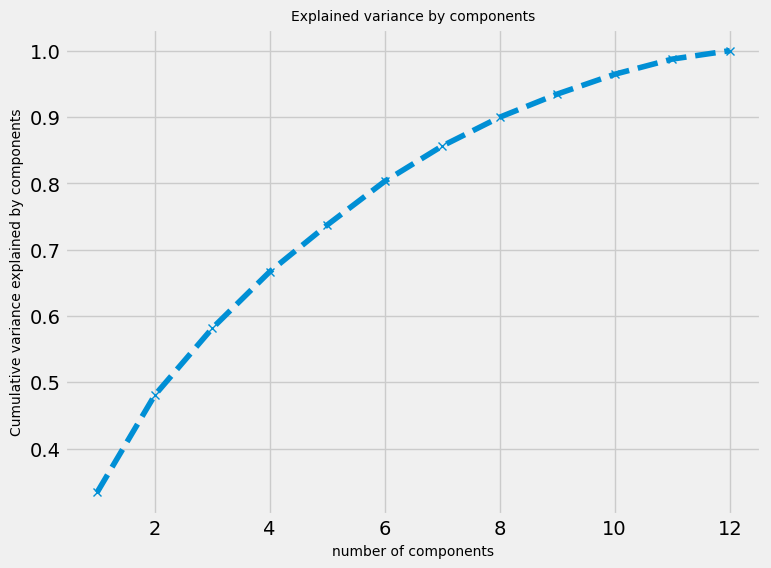

In [263]:
plt.figure(figsize=(8,6))
plt.plot(range(1,13), pca.explained_variance_ratio_.cumsum(), marker='x', linestyle="--")
plt.title('Explained variance by components', fontsize = 10)
plt.xlabel('number of components' , fontsize = 10)
plt.ylabel('Cumulative variance explained by components', fontsize = 10)

From the above graph we can see that when 6 components accounts for a variance of around 80% which is enough

In [264]:
pca6 = PCA(n_components=6)

In [265]:
pca6.fit(df1_scaled)

PCA(n_components=6)

In [266]:
pca6.transform(df1_scaled)
score_pca6 = pca6.transform(df1_scaled)

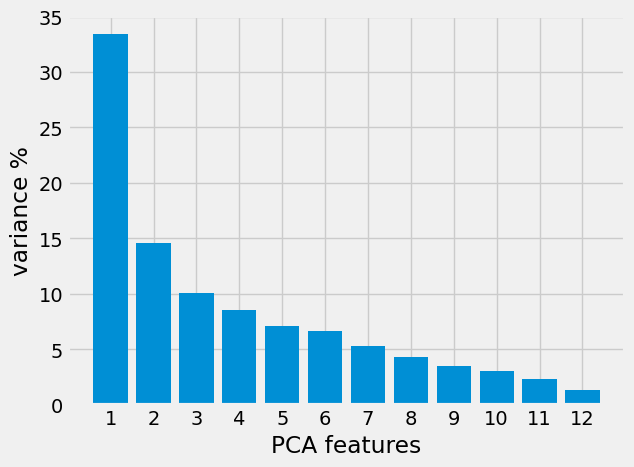

In [270]:
# Plot the explained variancesplt.figure(figsize=(10,10))
var = np.round(pca.explained_variance_ratio_*100, decimals = 1)
lbls = [str(x) for x in range(1,len(var)+1)]
plt.bar(x=range(1,len(var)+1), height = var, tick_label = lbls)
plt.xlabel('PCA features')
plt.ylabel('variance %')
plt.show()

The above figure shows that the first six components explain the majority of the variance in our data. For this visualization use case, we will quickly plot just the first two. We do this to notice if there are any clear clusters.

### K-Means Clustering

**We could either take a random K value or find the optimal K value using different methods like elbow method or Silohuette method**

##### Elbow Method
refers to plotting the variance explained by different numbers of clusters and identifying the “elbow” point, where the rate of variance decreases sharply levels off

In [271]:
wcss = []
for i in range(1,11):
    kmeans_pca = KMeans(n_clusters = i, init = 'k-means++', random_state=42, n_init=10)
    kmeans_pca.fit(score_pca6)
    wcss.append(kmeans_pca.inertia_)

In [272]:
!pip install kneed

DEPRECATION: Loading egg at c:\users\hermona\anaconda3\lib\site-packages\fonttools-4.43.1-py3.11.egg is deprecated. pip 23.3 will enforce this behaviour change. A possible replacement is to use pip for package installation..
DEPRECATION: Loading egg at c:\users\hermona\anaconda3\lib\site-packages\grad_cam-1.4.8-py3.11.egg is deprecated. pip 23.3 will enforce this behaviour change. A possible replacement is to use pip for package installation..


In [273]:
from kneed import KneeLocator
k1 = KneeLocator (range (1, 11), wcss, curve = "convex", direction = "decreasing")
k1.elbow

3

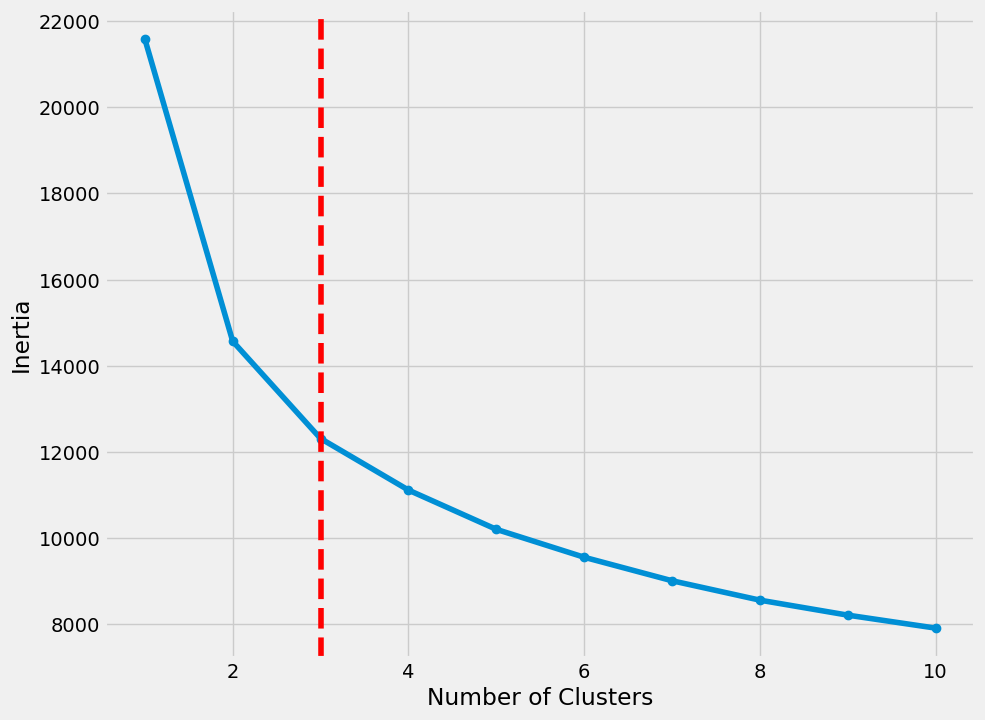

In [274]:
plt.style.use ("fivethirtyeight")
plt.figure(figsize=(10,8))
plt.plot(range(1,11), wcss, marker = 'o')
plt.xlabel ("Number of Clusters")
plt.ylabel ("Inertia")
plt.axvline ( x =k1.elbow, color = "red", label = "axvline - full height",linewidth = 4, linestyle ="--")
plt.show ()

from the above graph we could simply choose 3 as the number of clusters since the graph becomes smooth after that point

In [275]:
kmeans = KMeans(n_clusters= 3, init='k-means++', random_state= 20)
kmeans.fit_transform(score_pca6)

C:\Users\Hermona\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


array([[3.3293073 , 5.19641748, 2.97242969],
       [3.7078647 , 1.9560175 , 4.643998  ],
       [2.2789146 , 3.67529178, 2.0509516 ],
       ...,
       [3.62660299, 3.97469884, 2.09170335],
       [2.86977222, 4.23054404, 2.8207511 ],
       [2.46857778, 2.50295764, 4.61611222]])

In [276]:
pd.DataFrame(score_pca6)

,0,1,2,3,4,5
0,2.589914,1.413376,-1.209498,0.695902,1.628146,-0.556177
1,-1.636389,-1.114549,1.388400,-0.845562,0.765355,0.089787
2,1.512194,-0.100203,0.392120,-0.642388,-0.508853,-1.210339
3,-2.089308,-0.951422,-0.359891,-0.714418,-1.170196,0.201661
4,-0.286042,0.505508,0.838124,1.246985,-1.509247,1.225452
...,...,...,...,...,...,...
2235,0.878603,0.775202,0.309175,-0.098092,-0.156796,-0.167705
2236,-0.537685,2.508622,2.819581,-1.368031,0.349098,2.325451
2237,1.650869,-1.253856,-0.749737,1.563029,-0.683788,0.351676
2238,1.610084,-0.119318,1.562207,-1.650194,-0.494974,-0.645412


Now that we have found our principal components let us now add the labels

In [286]:
df1_pca_kmeans = pd.concat([df1.reset_index(drop=True), \
    pd.DataFrame(score_pca6)], axis=1)
df1_pca_kmeans.columns.values[-6:] = ['PC1', 'PC2','PC3', 'PC4','PC5','PC6']
df1_pca_kmeans['cluster'] = kmeans.labels_
df1_pca_kmeans.head()

,Age,Income,Recency,Family_Size,Cmp_accepted,NumDealsPurchases,Reg_Days,Tot_Products,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,PC1,PC2,PC3,PC4,PC5,PC6,cluster
0,67,58138.0,58,1,1,3,676,1617,8,10,4,7,2.589914,1.413376,-1.209498,0.695902,1.628146,-0.556177,2
1,70,46344.0,38,3,0,2,126,27,1,1,2,5,-1.636389,-1.114549,1.388400,-0.845562,0.765355,0.089787,1
2,59,71613.0,26,2,0,1,325,776,8,2,10,4,1.512194,-0.100203,0.392120,-0.642388,-0.508853,-1.210339,2
3,40,26646.0,26,3,0,2,152,53,2,0,4,6,-2.089308,-0.951422,-0.359891,-0.714418,-1.170196,0.201661,1
4,43,58293.0,94,3,0,5,174,422,5,3,6,5,-0.286042,0.505508,0.838124,1.246985,-1.509247,1.225452,0


In [287]:
df1_pca_kmeans ['cluster'] = df1_pca_kmeans ['cluster'].map({0: 'First', 1: 'Second', 2:'Third'})
df1_pca_kmeans.head()

,Age,Income,Recency,Family_Size,Cmp_accepted,NumDealsPurchases,Reg_Days,Tot_Products,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,PC1,PC2,PC3,PC4,PC5,PC6,cluster
0,67,58138.0,58,1,1,3,676,1617,8,10,4,7,2.589914,1.413376,-1.209498,0.695902,1.628146,-0.556177,Third
1,70,46344.0,38,3,0,2,126,27,1,1,2,5,-1.636389,-1.114549,1.388400,-0.845562,0.765355,0.089787,Second
2,59,71613.0,26,2,0,1,325,776,8,2,10,4,1.512194,-0.100203,0.392120,-0.642388,-0.508853,-1.210339,Third
3,40,26646.0,26,3,0,2,152,53,2,0,4,6,-2.089308,-0.951422,-0.359891,-0.714418,-1.170196,0.201661,Second
4,43,58293.0,94,3,0,5,174,422,5,3,6,5,-0.286042,0.505508,0.838124,1.246985,-1.509247,1.225452,First


In [296]:
df.iloc[:, 12:'column_name_17']

TypeError: cannot do positional indexing on Index with these indexers [column_name_12] of type str

<Axes: xlabel='PC2', ylabel='PC1'>

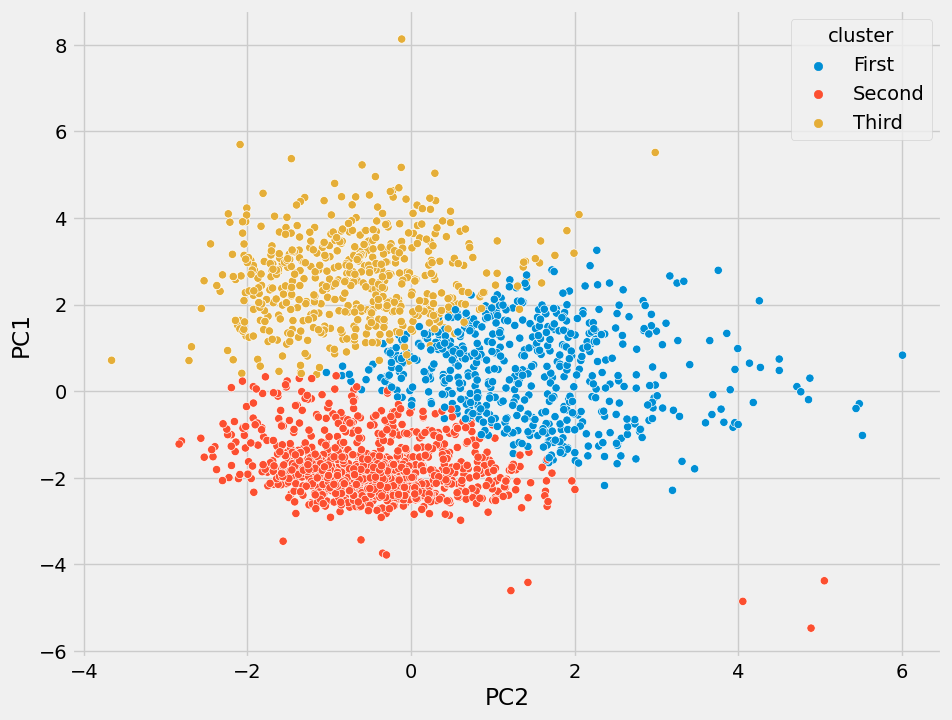

In [203]:
plt.figure(figsize = (10,8))
sns.scatterplot(x='PC2', y='PC1', data=df1_pca_kmeans, hue='cluster', hue_order=['First', 'Second','Third'])

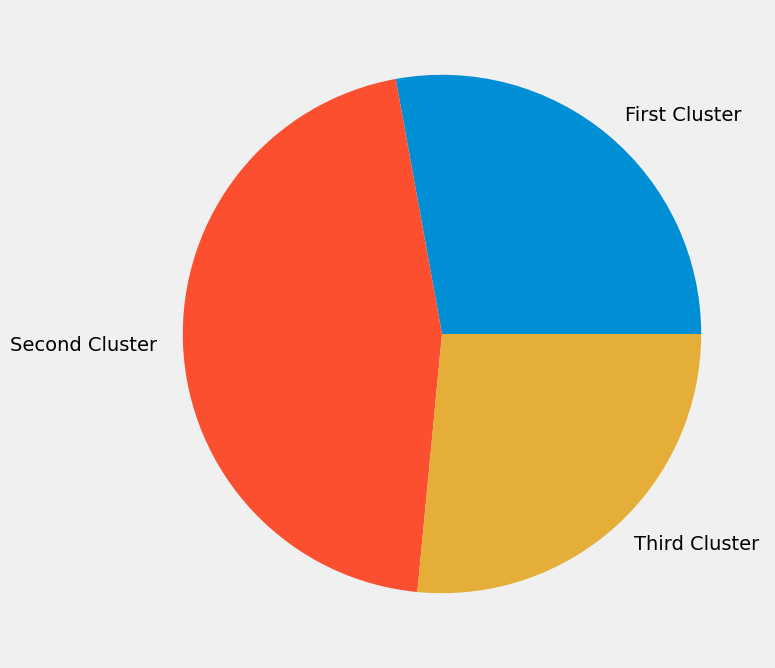

In [204]:
plt.figure(figsize = (8,8))
pie = df1_pca_kmeans.groupby(['cluster']).size().to_frame().reset_index()
pie.rename(columns={0: 'count'}, inplace=True)

pie_labels = ['First Cluster', 'Second Cluster', 'Third Cluster']
plt.pie(pie['count'], labels=pie_labels)
plt.show()

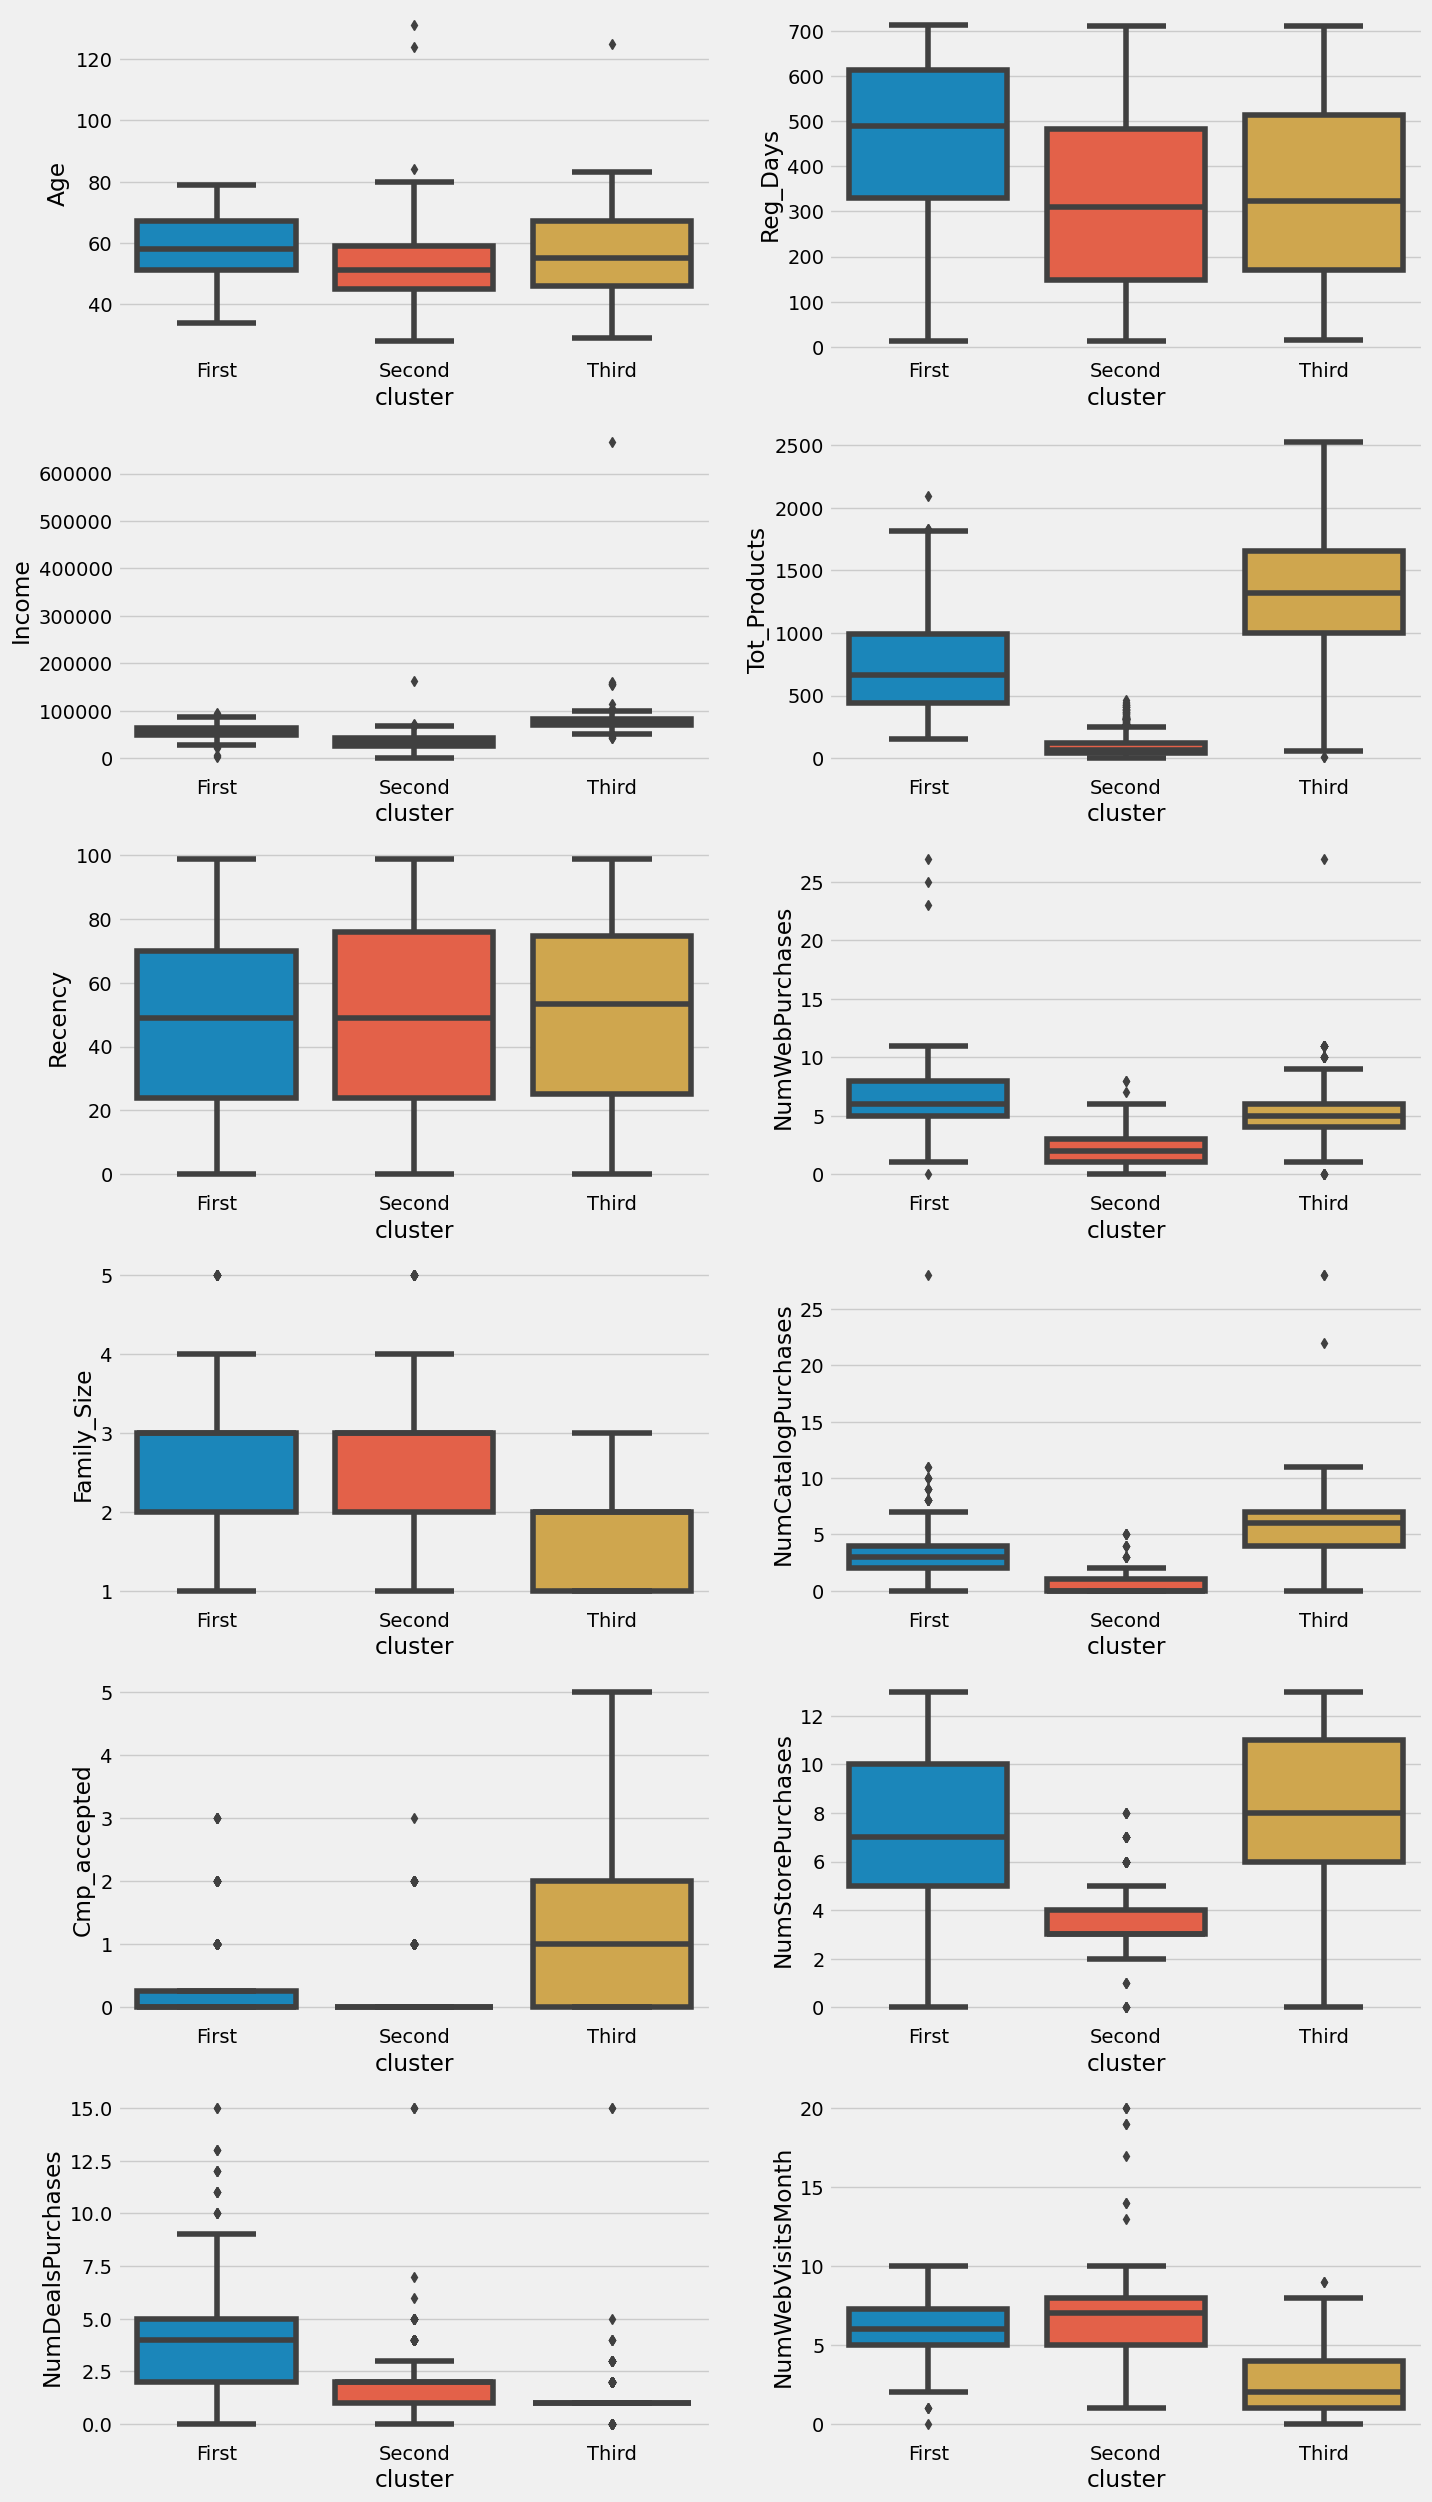

In [205]:
fig, axs = plt.subplots(ncols=2, nrows=6, figsize=(15,30))
for cols, x in zip(df1_pca_kmeans.columns[:6], range(6)):
    for y in range(1):
        sns.boxplot(y=cols, x='cluster', data=df1_pca_kmeans, order=['First', 'Second','Third'], ax=axs[x,y], showfliers = True )

for cols, x in zip(df1_pca_kmeans.columns[6:], range(6)):
    for y in range(1,2):
        sns.boxplot(y=cols, x='cluster', data=df1_pca_kmeans, order=['First', 'Second','Third'], ax=axs[x,y], showfliers = True )

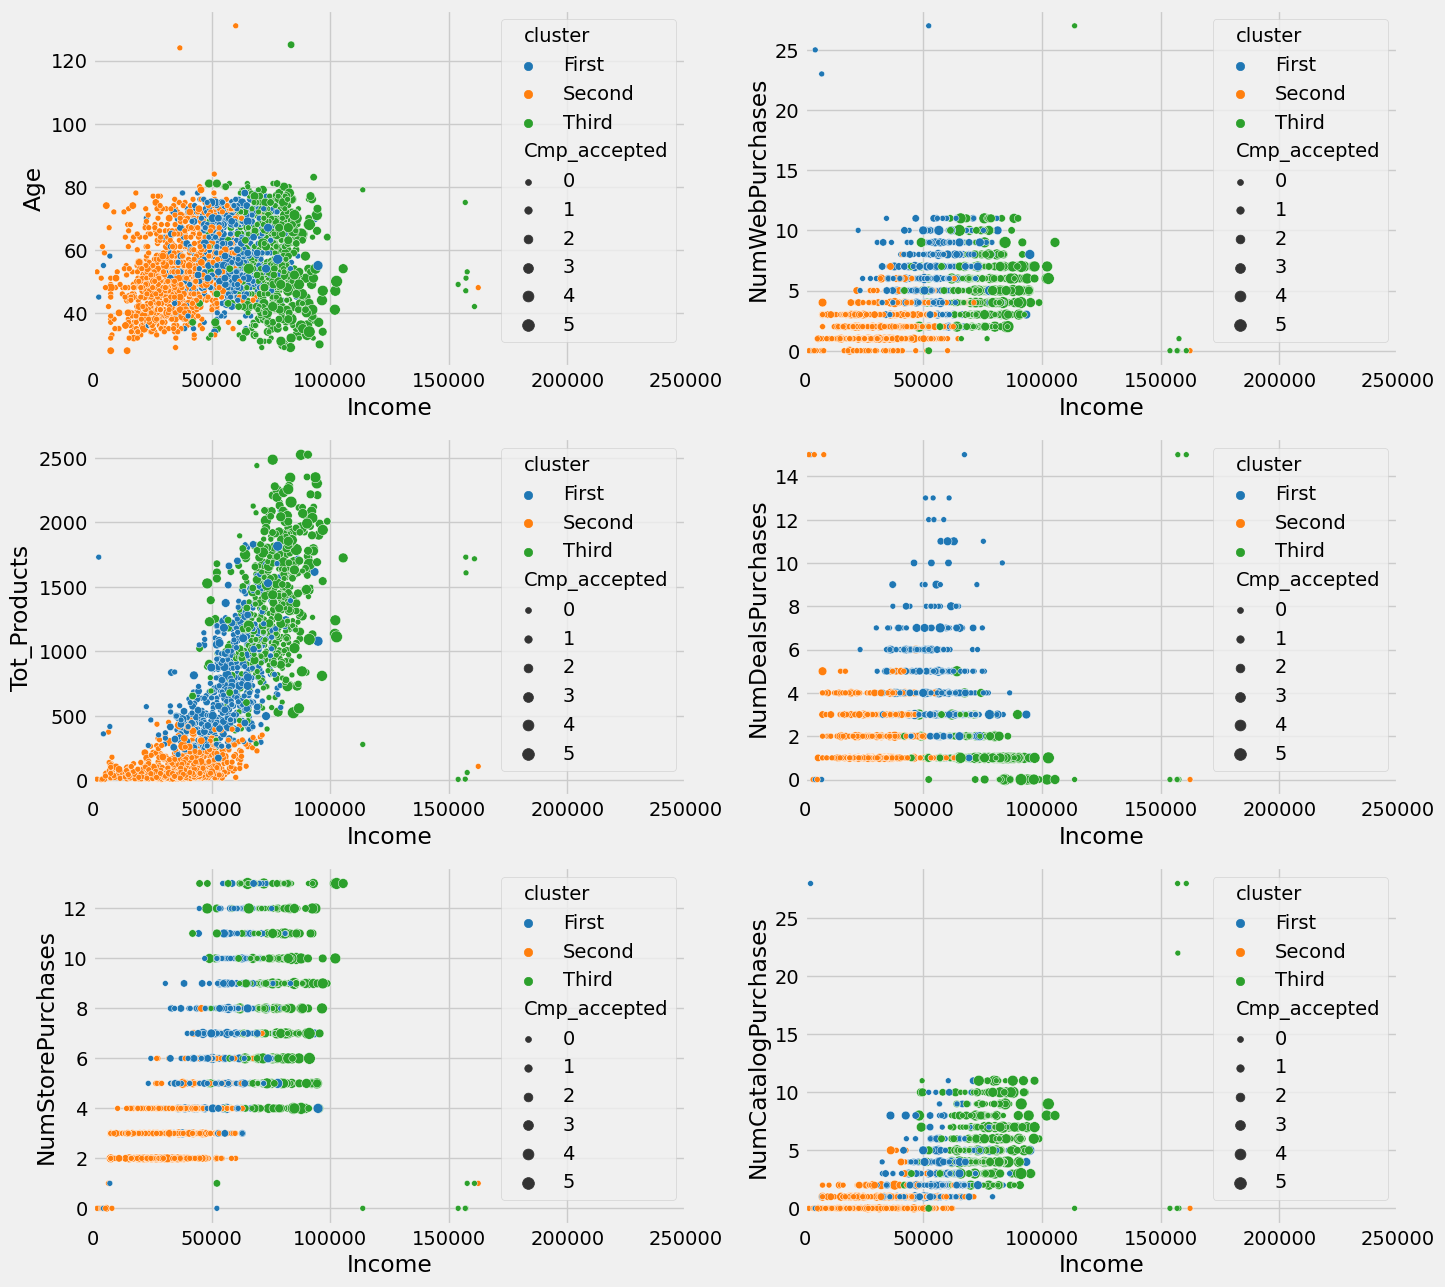

In [206]:
fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(15,15))

for cols, x in zip(['Age', 'Tot_Products','NumStorePurchases',], range(3)):
    for y in range(1):
        sns.scatterplot(x='Income',y=cols, data=df1_pca_kmeans, hue='cluster', size='Cmp_accepted' ,palette="tab10", ax=axs[x,y], hue_order=['First', 'Second','Third']).set(xlim=(0,250000))

for cols, x in zip(['NumWebPurchases','NumDealsPurchases','NumCatalogPurchases'], range(3)):
    for y in range(1,2):
        sns.scatterplot(x='Income',y=cols, data=df1_pca_kmeans, hue='cluster', size='Cmp_accepted' ,palette="tab10", ax=axs[x,y], hue_order=['First', 'Second','Third']).set(xlim=(0,250000))

#### Result Analysis

**First Group**

Customers in this group can be considered Average Customers. They buy average amount of products, most of them engage in only one campaign, ut they make more purchases when offered with a discount. They also shop more often online than the rest groups

**Second Group**

Customers in this group are low income customers who don't engage as they have low puchasing ability and spend little on the company. Majority don't participate in a campaign but they visit the online shop hompage regardless.

**Third Group**

Customers in this group in contrary to the above group have high income and high engagement (purchasing record). They usually have more campaigns and love to make purchases instores and don't visit the website much. They hae small family sizes and the discount is also not attractive to them.

### Conclusion

The pie chart reveals that the second group of customers is the largest, representing almost half of the total customer base. The sizes of the other two groups are relatively balanced.

This suggests that the company should focus on leveraging its existing customer base by offering additional products and services and launching marketing campaigns to encourage purchases from the first and third groups of customers.

Additionally, the company could increase its focus on promoting its online store to attract the second group of customers, who spend a significant amount of time browsing the website but make relatively few purchases.